# Machine Learning-Based Fertility Chance Classification: Computational Supplement

**A comparative evaluation of five classifiers with leakage-free preprocessing and SHAP explainability**

---

This notebook is the full computational supplement to the accompanying research paper. Every step is documented in the order it was executed. The pipeline can be run top-to-bottom to reproduce all reported results.

The study uses a synthetically generated dataset of 5,000 records. Performance figures reflect that synthetic signal and should not be interpreted as estimates of real clinical accuracy. The contribution of this work is the pipeline methodology — demonstrating leakage-free preprocessing, justified imputation choices, and patient-level SHAP explainability as a foundation for future validation on real clinical data.

**Target variable — three-class fertility chance:**

| Class | Meaning in this study |
|---|---|
| High | Profile consistent with no significant barriers identified |
| Moderate | Mixed profile — some factors present that warrant further assessment |
| Low | Multiple risk factors present — consistent with referral-indicated profile |

**Dataset:** 5,000 synthetic records · 26 features · Class split: High 40%, Moderate 32%, Low 28%  
**Structured missingness:** AMH 52% · Semen analysis 53% · FSH ~15–40% · TSH 18% · Vitamin D 21%

## Step 1 — Install & Import Libraries

In [20]:
!pip install imbalanced-learn shap xgboost lightgbm -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.compose  import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap




## Step 2 — Dataset

The dataset was generated synthetically to reflect characteristics of a general reproductive-age population, not a clinical help-seeking sample. Class distribution reflects a general population baseline: most people have no significant fertility barriers, which is why High is the majority class.



In [21]:
df = pd.read_csv('/content/fertility_final_5000_v8 (1).csv')

df.head(2)

,female_age,partner_age,months_trying,cycle_length,cycle_regular,ever_pregnant,live_births,miscarriages,ectopic,pcos,...,activity,sleep,stress,amh,fsh,tsh,vitd,semen_analysis,prior_infertility_dx,fertility_chance
0,24,26,18,28,1,0,0,0,0,1,...,moderate,9,2,NaN,5.238,2.769,25.1,normal,none,high
1,23,23,29,32,0,1,0,0,0,1,...,moderate,5,9,NaN,6.219,1.507,25.0,mild_issue,none,high


In [22]:
print(df.shape)


(5000, 26)


In [23]:
print('\nClass distribution:')
print(df['fertility_chance'].value_counts())


Class distribution:
fertility_chance
high        2011
moderate    1598
low         1391
Name: count, dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   female_age            5000 non-null   int64  
 1   partner_age           5000 non-null   int64  
 2   months_trying         5000 non-null   int64  
 3   cycle_length          5000 non-null   int64  
 4   cycle_regular         5000 non-null   int64  
 5   ever_pregnant         5000 non-null   int64  
 6   live_births           5000 non-null   int64  
 7   miscarriages          5000 non-null   int64  
 8   ectopic               5000 non-null   int64  
 9   pcos                  5000 non-null   int64  
 10  endometriosis         5000 non-null   int64  
 11  thyroid               5000 non-null   int64  
 12  diabetes              5000 non-null   int64  
 13  bmi                   5000 non-null   float64
 14  smoking               5000 non-null   object 
 15  alcohol              

In [6]:
print(df.isnull().sum())

female_age                 0
partner_age                0
months_trying              0
cycle_length               0
cycle_regular              0
ever_pregnant              0
live_births                0
miscarriages               0
ectopic                    0
pcos                       0
endometriosis              0
thyroid                    0
diabetes                   0
bmi                        0
smoking                    0
alcohol                    0
activity                   0
sleep                      0
stress                     0
amh                     2618
fsh                     1587
tsh                      877
vitd                    1049
semen_analysis          2647
prior_infertility_dx       0
fertility_chance           0
dtype: int64


In [7]:
cols=['cycle_regular', 'ever_pregnant', 'ectopic', 'pcos', 'endometriosis', 'thyroid', 'diabetes']
df[cols]=df[cols].astype(bool)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   female_age            5000 non-null   int64  
 1   partner_age           5000 non-null   int64  
 2   months_trying         5000 non-null   int64  
 3   cycle_length          5000 non-null   int64  
 4   cycle_regular         5000 non-null   bool   
 5   ever_pregnant         5000 non-null   bool   
 6   live_births           5000 non-null   int64  
 7   miscarriages          5000 non-null   int64  
 8   ectopic               5000 non-null   bool   
 9   pcos                  5000 non-null   bool   
 10  endometriosis         5000 non-null   bool   
 11  thyroid               5000 non-null   bool   
 12  diabetes              5000 non-null   bool   
 13  bmi                   5000 non-null   float64
 14  smoking               5000 non-null   object 
 15  alcohol              

**Variable notes:**
- `alcohol` — US standard drinks per week (NIAAA definition: 1 drink = 14g pure alcohol)
- `smoking` — never / former / light / moderate / heavy
- `activity` — sedentary / light / moderate / active / very_active
- `semen_analysis` — normal / mild_issue / moderate_issue / severe_issue · **53% missing** (partner not tested — the most common pre-screening scenario)
- `amh` — **52% missing** (specialist-ordered ovarian reserve test, rarely available before formal assessment)
- `fsh` — missing ~15% for irregular cycles, ~40% for regular cycles (irregular cycles are a clinical red flag that prompts investigation — a structured MAR pattern confirmed by chi-square, χ²=290.5, p<0.001)
- `tsh` — 18% missing · `vitd` — 21% missing
- Binary columns (0/1): `cycle_regular`, `ever_pregnant`, `ectopic`, `pcos`, `endometriosis`, `thyroid`, `diabetes`

## Step 2b — Descriptive Statistics

Summary statistics for all numerical features. Mean, standard deviation, and range are reported across the full dataset prior to splitting. This table corresponds to Table 1 in the paper.

In [9]:
# Descriptive statistics for all numerical features
# This produces the Table 1 equivalent expected by clinical ML reviewers

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

desc_stats = df[numerical_cols].describe().round(2)
print('Descriptive Statistics — Numerical Features')

print(desc_stats.to_string())

# Per-class means for key clinical variables
print('\nPer-Class Means — Key Clinical Variables')

key_cols = ['female_age', 'amh', 'fsh', 'tsh', 'vitd', 'bmi', 'stress', 'sleep', 'months_trying']
print(df.groupby('fertility_chance')[key_cols].mean().round(2).to_string())

# Export to CSV for paper Table 1
desc_stats.to_csv('descriptive_statistics.csv')
print('\nSaved to descriptive_statistics.csv')

Descriptive Statistics — Numerical Features
       female_age  partner_age  months_trying  cycle_length  live_births  miscarriages      bmi  alcohol    sleep   stress      amh      fsh      tsh     vitd
count     5000.00      5000.00        5000.00       5000.00      5000.00       5000.00  5000.00  5000.00  5000.00  5000.00  2382.00  3413.00  4123.00  3951.00
mean        30.51        32.09          26.10         30.02         0.42          0.16    25.07    10.39     6.98     5.44     2.06    10.06     2.98    27.96
std          6.14         6.78          15.41          4.46         0.80          0.41     4.03     6.41     1.99     2.86     1.71     5.22     1.33     9.53
min         18.00        18.00           1.00         21.00         0.00          0.00    17.50     0.00     4.00     1.00     0.10     1.00     0.40     5.00
25%         26.00        27.00          13.75         26.00         0.00          0.00    22.10     5.00     5.00     3.00     0.68     6.07     2.00    21.50
50

## Step 3 — Exploratory Data Analysis

Visualising what separates High, Moderate, and Low fertility chance patients.

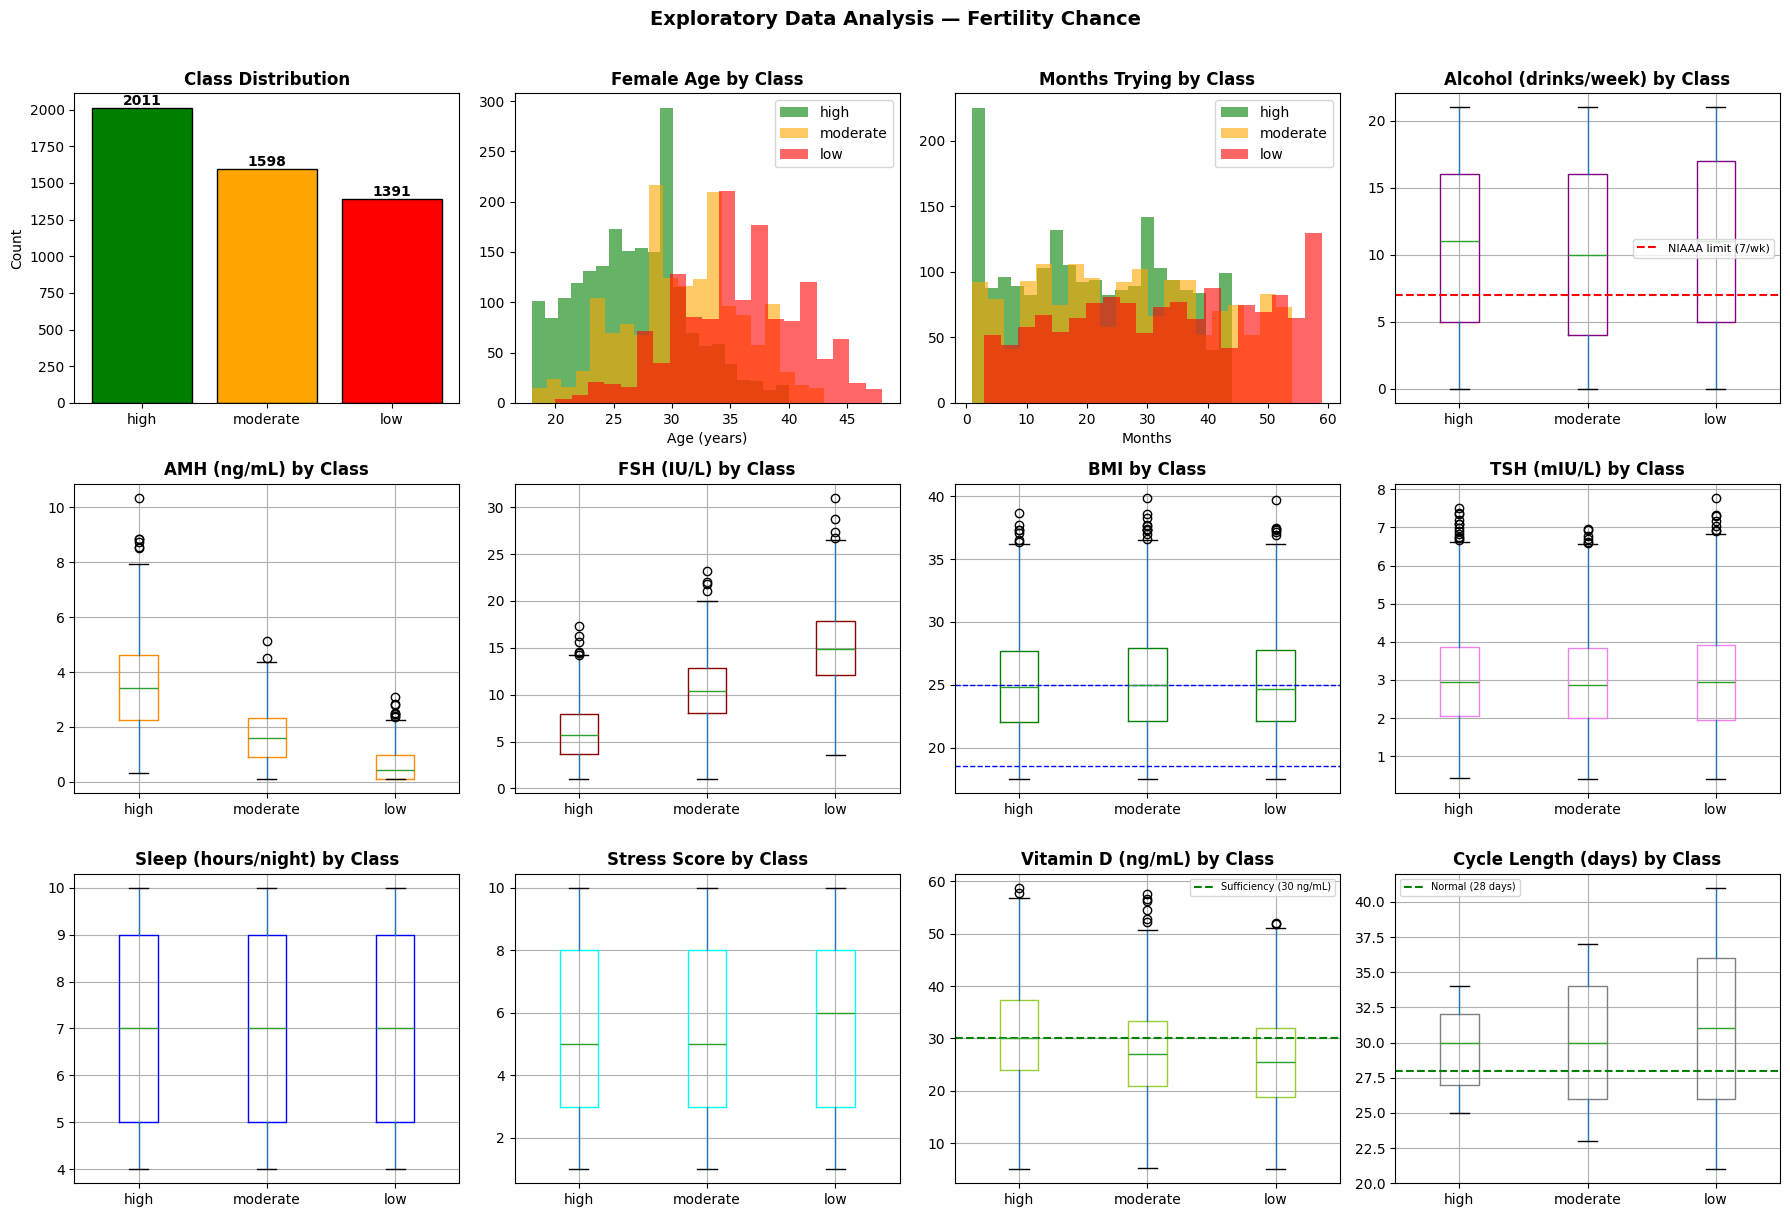

In [24]:
colors      = ['green', 'orange', 'red']
class_order = ['high', 'moderate', 'low']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

counts = [df[df['fertility_chance']==c].shape[0] for c in class_order]
axes[0,0].bar(class_order, counts, color=colors, edgecolor='black')
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0,0].text(i, v+20, str(v), ha='center', fontweight='bold')

for i, cls in enumerate(class_order):
    axes[0,1].hist(df[df['fertility_chance']==cls]['female_age'],
                   bins=20, alpha=0.6, label=cls, color=colors[i])
axes[0,1].set_title('Female Age by Class', fontweight='bold')
axes[0,1].legend(); axes[0,1].set_xlabel('Age (years)')

for i, cls in enumerate(class_order):
    axes[0,2].hist(df[df['fertility_chance']==cls]['months_trying'],
                   bins=20, alpha=0.6, label=cls, color=colors[i])
axes[0,2].set_title('Months Trying by Class', fontweight='bold')
axes[0,2].legend(); axes[0,2].set_xlabel('Months')

df_plot = df.copy()
df_plot['fertility_chance'] = pd.Categorical(df_plot['fertility_chance'], class_order)
df_plot.sort_values('fertility_chance', inplace=True)
df_plot.boxplot(column='alcohol', by='fertility_chance', ax=axes[0,3], boxprops=dict(color='purple'))
axes[0,3].set_title('Alcohol (drinks/week) by Class', fontweight='bold')
axes[0,3].axhline(7, color='red', lw=1.5, linestyle='--', label='NIAAA limit (7/wk)')
axes[0,3].legend(fontsize=8); plt.sca(axes[0,3]); plt.xlabel('')

df_plot.boxplot(column='amh', by='fertility_chance', ax=axes[1,0], boxprops=dict(color='darkorange'))
axes[1,0].set_title('AMH (ng/mL) by Class', fontweight='bold')
plt.sca(axes[1,0]); plt.xlabel('')

df_plot.boxplot(column='fsh', by='fertility_chance', ax=axes[1,1], boxprops=dict(color='darkred'))
axes[1,1].set_title('FSH (IU/L) by Class', fontweight='bold')
plt.sca(axes[1,1]); plt.xlabel('')

df_plot.boxplot(column='bmi', by='fertility_chance', ax=axes[1,2], boxprops=dict(color='green'))
axes[1,2].set_title('BMI by Class', fontweight='bold')
axes[1,2].axhline(18.5, color='blue', lw=1, linestyle='--')
axes[1,2].axhline(25,   color='blue', lw=1, linestyle='--')
plt.sca(axes[1,2]); plt.xlabel('')

df_plot.boxplot(column='tsh', by='fertility_chance', ax=axes[1,3], boxprops=dict(color='violet'))
axes[1,3].set_title('TSH (mIU/L) by Class', fontweight='bold')
plt.sca(axes[1,3]); plt.xlabel('')

df_plot.boxplot(column='sleep', by='fertility_chance', ax=axes[2,0], boxprops=dict(color='blue'))
axes[2,0].set_title('Sleep (hours/night) by Class', fontweight='bold')
plt.sca(axes[2,0]); plt.xlabel('')

df_plot.boxplot(column='stress', by='fertility_chance', ax=axes[2,1], boxprops=dict(color='cyan'))
axes[2,1].set_title('Stress Score by Class', fontweight='bold')
plt.sca(axes[2,1]); plt.xlabel('')

df_plot.boxplot(column='vitd', by='fertility_chance', ax=axes[2,2], boxprops=dict(color='yellowgreen'))
axes[2,2].set_title('Vitamin D (ng/mL) by Class', fontweight='bold')
axes[2,2].axhline(30, color='green', lw=1.5, linestyle='--', label='Sufficiency (30 ng/mL)')
axes[2,2].legend(fontsize=7); plt.sca(axes[2,2]); plt.xlabel('')

df_plot.boxplot(column='cycle_length', by='fertility_chance', ax=axes[2,3], boxprops=dict(color='gray'))
axes[2,3].set_title('Cycle Length (days) by Class', fontweight='bold')
axes[2,3].axhline(28, color='green', lw=1.5, linestyle='--', label='Normal (28 days)')
axes[2,3].legend(fontsize=7); plt.sca(axes[2,3]); plt.xlabel('')

plt.suptitle('Exploratory Data Analysis — Fertility Chance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

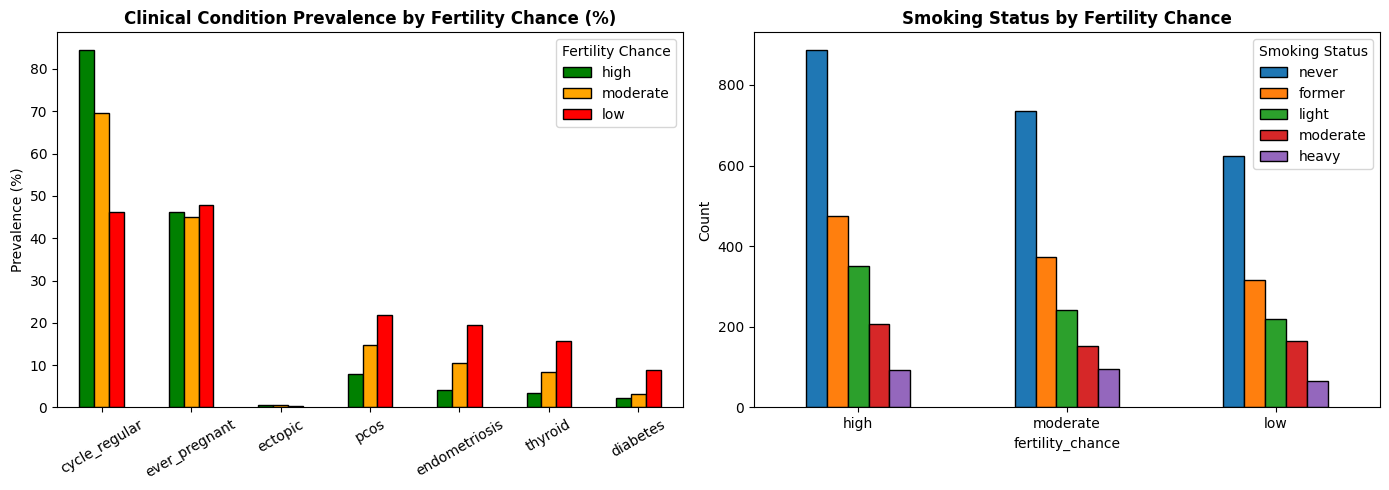

In [25]:
bool_cols = ['cycle_regular','ever_pregnant','ectopic','pcos','endometriosis','thyroid','diabetes']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tmp = df.copy()
tmp['fertility_chance'] = pd.Categorical(tmp['fertility_chance'], class_order)
tmp.sort_values('fertility_chance', inplace=True)
tmp.groupby('fertility_chance')[bool_cols].mean().mul(100).T.plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Clinical Condition Prevalence by Fertility Chance (%)', fontweight='bold')
axes[0].set_ylabel('Prevalence (%)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Fertility Chance')
smoking_counts = df.groupby(['fertility_chance','smoking']).size().unstack(fill_value=0)
smoking_order  = ['never','former','light','moderate','heavy']
smoking_counts = smoking_counts.reindex(columns=[c for c in smoking_order if c in smoking_counts.columns])
smoking_counts.loc[class_order].plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Smoking Status by Fertility Chance', fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Smoking Status')
plt.tight_layout(); plt.show()

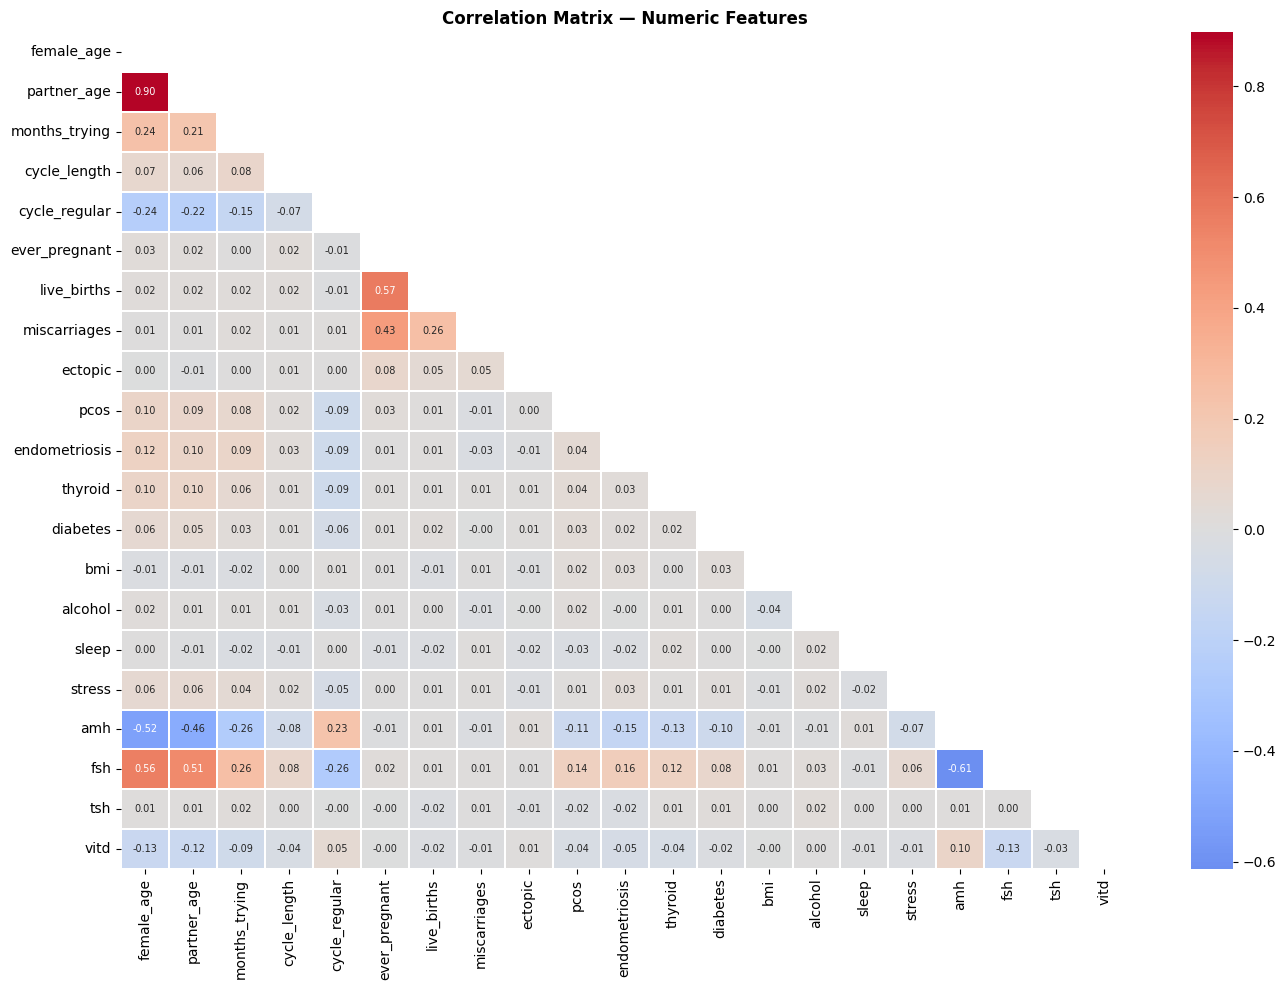

In [26]:
# Correlation heatmap — lower triangle only to avoid redundancy and to look clean
numeric_cols        = df.select_dtypes(include=np.number).columns.tolist()
upper_triangle_mask = np.triu(np.ones(len(numeric_cols), dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    df[numeric_cols].corr(), mask=upper_triangle_mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing & Feature Engineering

Strict no-leakage order:
1. Train/test split (80/20 stratified) — first step, before anything else
2. IQR Capping  on BMI, alcohol, months_trying — bounds fitted on train only
3. Ordinal encoding of categorical variables
4. Missingness indicator flags — added before imputation so the model learns from what was missing
5. MICE imputation — fitted on train only
6. Binary clinical threshold features — e.g. prime_age, healthy_bmi, good_amh
7. Composite interaction features — e.g. lifestyle_score, biomarker_score
8. StandardScaler via ColumnTransformer — continuous features only
9. SMOTE — inside ImbPipeline, training folds only

In [27]:
# Encode the target: high=2, moderate=1, low=0
label_map = {'high': 2, 'moderate': 1, 'low': 0}

data = df.copy()
data['target'] = data['fertility_chance'].map(label_map)

X = data.drop(columns=['fertility_chance', 'target'])
y = data['target']

# Split FIRST — all preprocessing is fitted only on training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print('\nClass distribution in training set:')
print(y_train.value_counts().sort_index().rename({0: 'Low', 1: 'Moderate', 2: 'High'}))

Training set : (4000, 25)
Test set     : (1000, 25)

Class distribution in training set:
target
Low         1113
Moderate    1278
High        1609
Name: count, dtype: int64


In [31]:
# IQR iutlier capping — cap extreme values using bounds derived from training data only.
# Fence parameters (Q1 - 1.5*IQR, Q3 + 1.5*IQR) are estimated from X_train
# and applied to both splits — this is the no-leakage requirement.
# outlier caps rather than deletes extreme values, preserving all records.

outlier_cols = ['bmi', 'alcohol', 'months_trying']

for col in outlier_cols:
    q1, q3       = X_train[col].quantile([0.25, 0.75])
    iqr          = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

# Hard clinical cap: 36 months (3 years) is the standard referral threshold
X_train['months_trying'] = X_train['months_trying'].clip(upper=36)
X_test['months_trying']  = X_test['months_trying'].clip(upper=36)

print('Post-Outlier capping ranges (training set):')
for col in outlier_cols:
    print(f'  {col}: {X_train[col].min():.2f} - {X_train[col].max():.2f}')



Post-Outlier capping ranges (training set):
  bmi: 17.50 - 36.35
  alcohol: 0.00 - 21.00
  months_trying: 1.00 - 36.00


In [32]:
# Ordinal encoding — maps categories to ordered integers reflecting clinical severity
ordinal_maps = {
    'smoking':              {'never': 0, 'former': 1, 'light': 2, 'moderate': 3, 'heavy': 4},
    'activity':             {'sedentary': 0, 'light': 1, 'moderate': 2, 'active': 3, 'very_active': 4},
    'semen_analysis':       {'severe_issue': 0, 'moderate_issue': 1, 'mild_issue': 2, 'normal': 3},
    'prior_infertility_dx': {'confirmed': 0, 'possible': 1, 'none': 2},
}

if X_train['smoking'].dtype == object:
    for split in [X_train, X_test]:
        for col, mapping in ordinal_maps.items():
            split[col] = split[col].map(mapping)
    print('Ordinal encoding applied.')
else:
    print('Already encoded — skipping.')


# These flags let the model learn from which values were missing
cols_with_missing = ['amh', 'fsh', 'tsh', 'vitd', 'semen_analysis']

for split in [X_train, X_test]:
    for col in cols_with_missing:
        split[f'{col}_missing'] = split[col].isnull().astype(int)


# MICE (Multiple Imputation by Chained Equations) — fitted on training data only.
# AMH and FSH are correlated at -0.54, so MICE can use that

imputer = IterativeImputer(max_iter=10, random_state=42, verbose=0)

X_train[cols_with_missing] = imputer.fit_transform(X_train[cols_with_missing])
X_test[cols_with_missing]  = imputer.transform(X_test[cols_with_missing])  # transform only

remaining_nulls = X_train.isnull().sum().sum() + X_test.isnull().sum().sum()
print(f'Missing values after imputation: {remaining_nulls} (expected 0)')

Ordinal encoding applied.
Missing values after imputation: 0 (expected 0)


In [ ]:
def add_clinical_threshold_features(df_split):
    """Add binary flags based on established clinical cutoffs."""
    df_split['prime_age']      = ((df_split['female_age'] >= 20) & (df_split['female_age'] <= 35)).astype(int)
    df_split['healthy_bmi']    = ((df_split['bmi'] >= 18.5) & (df_split['bmi'] <= 25)).astype(int)
    df_split['good_amh']       = (df_split['amh'] >= 1.5).astype(int)      # ng/mL threshold
    df_split['normal_fsh']     = (df_split['fsh'] <= 8.0).astype(int)      # IU/L threshold
    df_split['optimal_vitd']   = (df_split['vitd'] >= 30).astype(int)      # ng/mL sufficiency cutoff
    df_split['low_alcohol']    = (df_split['alcohol'] <= 7).astype(int)    # NIAAA weekly limit
    df_split['healthy_habits'] = (
        (df_split['smoking'] == 0).astype(int)    # non-smoker
        + df_split['low_alcohol']                  # within alcohol limit
        + (df_split['sleep'] >= 7).astype(int)    # adequate sleep
        + (df_split['activity'] >= 2).astype(int) # at least moderate activity
    )
    df_split['no_diagnosis'] = (~(
        df_split['pcos'].astype(bool)
        | df_split['endometriosis'].astype(bool)
        | df_split['thyroid'].astype(bool)
        | df_split['diabetes'].astype(bool)
    )).astype(int)


def add_interaction_features(df_split):
    """Add composite features that capture multi-variable interactions."""
    # How many of the three main biomarkers are in a healthy range
    df_split['biomarker_score']  = df_split['good_amh'] + df_split['normal_fsh'] + df_split['optimal_vitd']

    # Total count of diagnosed reproductive conditions
    df_split['total_conditions'] = (
        df_split['pcos'] + df_split['endometriosis'] + df_split['thyroid'] + df_split['diabetes']
    ).astype(int)

    # Reproductive history score: pregnancies are positive, losses are negative
    df_split['repro_history']    = (
        df_split['ever_pregnant'].astype(int) * 2
        - df_split['miscarriages']
        - df_split['ectopic'].astype(int) * 2
    )

    # Combined lifestyle score (good habits minus stress)
    df_split['lifestyle_score']  = df_split['healthy_habits'] - df_split['stress'] / 3.0

    # AMH relative to age — ovarian reserve declines with age, so ratio adds context
    df_split['amh_age_ratio']    = df_split['amh'] / (df_split['female_age'] + 1)

    # FSH x age — rising FSH is more concerning at older ages
    df_split['fsh_age']          = df_split['fsh'] * df_split['female_age'] / 100

    # Non-linear age effect (fertility decline accelerates after 35)
    df_split['age_squared']      = df_split['female_age'] ** 2 / 1000

    # Log of months trying — diminishing information at long durations
    df_split['months_log']       = np.log1p(df_split['months_trying'])

    # How far BMI deviates from the clinical optimum (~22)
    df_split['bmi_deviation']    = (df_split['bmi'] - 22) ** 2

    # Stress compounded by poor sleep — a known negative combination
    df_split['stress_sleep']     = df_split['stress'] * (1.0 / (df_split['sleep'] + 0.1))

    # Conditions become more impactful as the patient gets older
    df_split['condition_age']    = df_split['total_conditions'] * df_split['female_age']

    # Alcohol impact scaled by age
    df_split['alcohol_age']      = df_split['alcohol'] * df_split['female_age'] / 100


for split in [X_train, X_test]:
    add_clinical_threshold_features(split)
    add_interaction_features(split)

print(f'Original features    : 26')
print(f'Engineered features  : {X_train.shape[1] - 26}')
print(f'Total features       : {X_train.shape[1]}')

Original features    : 26
Engineered features  : 24
Total features       : 50


## Step 5 — Model Training and Comparison

Five classifiers are evaluated alongside a Soft-Voting Ensemble. Each is assessed using five-fold stratified cross-validation with macro-averaged F1 as the primary selection metric — this weights all three classes equally, which is appropriate for a general pre-screening population where no single prognosis group is clinically prioritised.

SMOTE is placed inside each cross-validation fold via ImbPipeline — not applied before CV begins. This is the critical distinction: applying SMOTE externally before cross-validation allows synthetic minority samples to be generated from data that subsequently appears in validation folds, inflating CV estimates. The ImbPipeline approach prevents this entirely.

**Depth note:** Gradient Boosting uses `max_depth=2` (standard conservative configuration). XGBoost uses `max_depth=4` to capture higher-order interactions (AMH × FSH × age × condition burden) that shallow trees resolve across multiple sequential splits.

In [ ]:
# Columns that should NOT be scaled (already on a meaningful 0/1 or small integer scale)
binary_cols = [
    'cycle_regular', 'ever_pregnant', 'pcos', 'endometriosis', 'thyroid', 'diabetes',
    'amh_missing', 'fsh_missing', 'tsh_missing', 'vitd_missing', 'semen_analysis_missing',
    'prime_age', 'healthy_bmi', 'good_amh', 'normal_fsh', 'optimal_vitd', 'low_alcohol', 'no_diagnosis',
]
count_cols = [
    'healthy_habits', 'biomarker_score', 'total_conditions',
    'live_births', 'miscarriages', 'ectopic'
]
do_not_scale = set(binary_cols + count_cols)
scale_these  = [col for col in X_train.columns if col not in do_not_scale]

# Scale continuous features only; leave binary/count features as-is
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), scale_these)
], remainder='passthrough')


def build_pipeline(model):
    """Wrap a model in a full preprocessing + SMOTE pipeline."""
    return ImbPipeline([
        ('preprocess', preprocessor),
        ('smote',      SMOTE(random_state=42, k_neighbors=5)),
        ('model',      model)
    ])


candidate_models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=2, learning_rate=0.1, subsample=0.8, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        eval_metric='mlogloss', random_state=42, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, num_leaves=31, learning_rate=0.1,
        subsample=0.8, min_child_samples=20, random_state=42, verbose=-1
    ),
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

header = f"{'Model':<25} | {'CV F1':>10} | {'+-Std':>6} | {'Test F1':>8} | {'Accuracy':>9} | {'Low':>7} | {'Mod':>7} | {'High':>7}"
print(header)


for name, model in candidate_models.items():
    pipeline = build_pipeline(model)

    cv_scores   = cross_val_score(pipeline, X_train, y_train, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
    pipeline.fit(X_train, y_train)
    y_pred_test = pipeline.predict(X_test)

    results[name] = {
        'cv_mean':     cv_scores.mean(),
        'cv_std':      cv_scores.std(),
        'test_f1':     f1_score(y_test, y_pred_test, average='macro'),
        'accuracy':    accuracy_score(y_test, y_pred_test),
        'recall_low':  recall_score(y_test, y_pred_test, labels=[0], average='macro'),
        'recall_mod':  recall_score(y_test, y_pred_test, labels=[1], average='macro'),
        'recall_high': recall_score(y_test, y_pred_test, labels=[2], average='macro'),
        'pipeline':    pipeline,
        'y_pred':      y_pred_test
    }
    r = results[name]
    print(
        f"{name:<25} | {r['cv_mean']:>10.4f} | {r['cv_std']:>6.4f} | "
        f"{r['test_f1']:>8.4f} | {r['accuracy']:>9.4f} | "
        f"{r['recall_low']:>7.4f} | {r['recall_mod']:>7.4f} | {r['recall_high']:>7.4f}"
    )


# Soft-Voting Ensemble: combines probability outputs from three strong models
ensemble = build_pipeline(
    VotingClassifier(voting='soft', estimators=[
        ('xgb', candidate_models['XGBoost']),
        ('lgb', candidate_models['LightGBM']),
        ('rf',  candidate_models['Random Forest']),
    ])
)
cv_ens     = cross_val_score(ensemble, X_train, y_train, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

results['Soft-Voting Ensemble'] = {
    'cv_mean':     cv_ens.mean(),
    'cv_std':      cv_ens.std(),
    'test_f1':     f1_score(y_test, y_pred_ens, average='macro'),
    'accuracy':    accuracy_score(y_test, y_pred_ens),
    'recall_low':  recall_score(y_test, y_pred_ens, labels=[0], average='macro'),
    'recall_mod':  recall_score(y_test, y_pred_ens, labels=[1], average='macro'),
    'recall_high': recall_score(y_test, y_pred_ens, labels=[2], average='macro'),
    'pipeline':    ensemble,
    'y_pred':      y_pred_ens
}
r = results['Soft-Voting Ensemble']
print(
    f"{'Soft-Voting Ensemble':<25} | {r['cv_mean']:>10.4f} | {r['cv_std']:>6.4f} | "
    f"{r['test_f1']:>8.4f} | {r['accuracy']:>9.4f} | "
    f"{r['recall_low']:>7.4f} | {r['recall_mod']:>7.4f} | {r['recall_high']:>7.4f}"
)


# Pick the best model by cross-validation F1
best_name     = max(results, key=lambda name: results[name]['cv_mean'])
best_pipeline = results[best_name]['pipeline']
y_pred        = results[best_name]['y_pred']

print(f'\nBest model  : {best_name}')
print(f'CV Macro F1 : {results[best_name]["cv_mean"]:.4f} (+-{results[best_name]["cv_std"]:.4f})')
print(f'Test F1     : {results[best_name]["test_f1"]:.4f}')
print(f'Accuracy    : {results[best_name]["accuracy"]:.4f}')

Model                     |      CV F1 |  +-Std |  Test F1 |  Accuracy |     Low |     Mod |    High
Logistic Regression       |     0.7063 | 0.0096 |   0.7214 |    0.7240 |  0.7806 |  0.6156 |  0.7711
Random Forest             |     0.7375 | 0.0107 |   0.7484 |    0.7530 |  0.8058 |  0.6312 |  0.8134
Gradient Boosting         |     0.7715 | 0.0127 |   0.7823 |    0.7850 |  0.8237 |  0.6844 |  0.8383
XGBoost                   |     0.7739 | 0.0132 |   0.7893 |    0.7940 |  0.8237 |  0.6719 |  0.8706
LightGBM                  |     0.7712 | 0.0130 |   0.7736 |    0.7790 |  0.8094 |  0.6438 |  0.8657
Soft-Voting Ensemble      |     0.7724 | 0.0128 |   0.7786 |    0.7840 |  0.8273 |  0.6469 |  0.8632

Best model  : XGBoost
CV Macro F1 : 0.7739 (+-0.0132)
Test F1     : 0.7893
Accuracy    : 0.7940


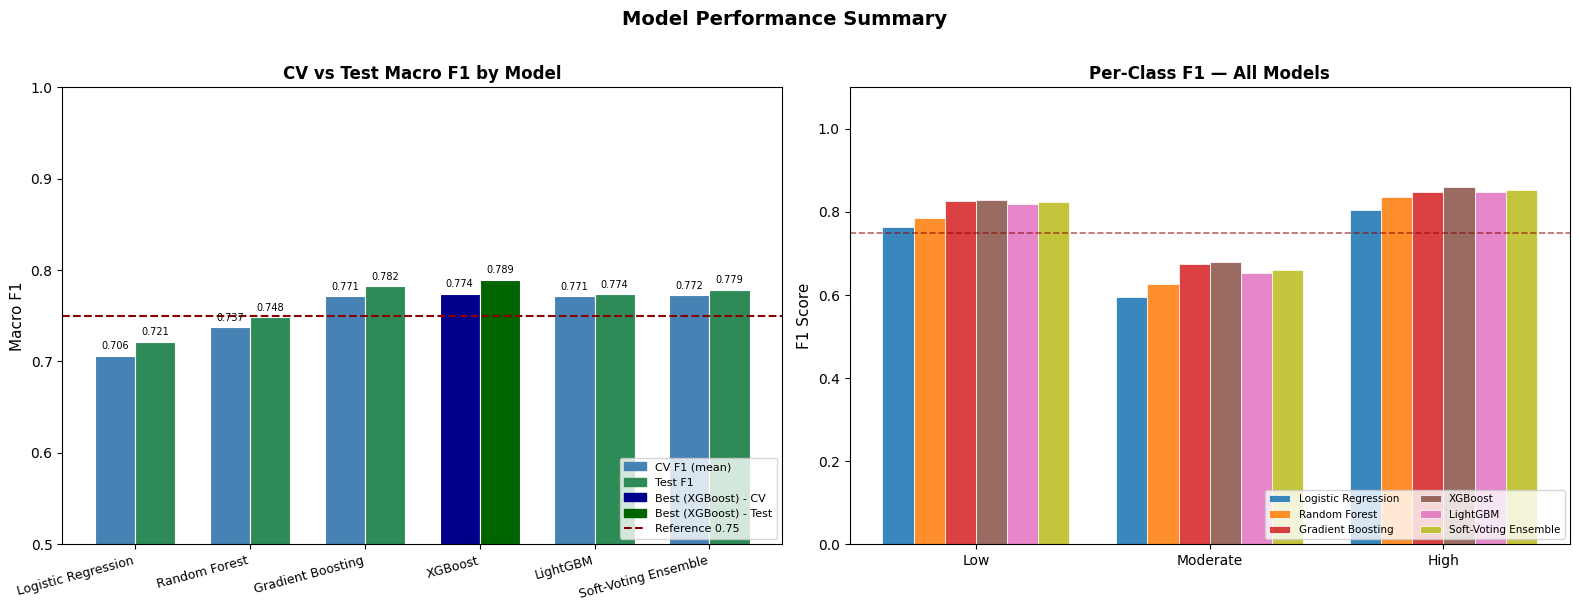

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(results.keys())
cv_means    = [results[n]['cv_mean'] for n in model_names]
test_f1s    = [results[n]['test_f1']  for n in model_names]

# Highlight the best model in a darker shade
cv_colors   = ['darkblue'  if n == best_name else 'steelblue' for n in model_names]
test_colors = ['darkgreen' if n == best_name else 'seagreen'  for n in model_names]

x_pos     = np.arange(len(model_names))
bar_width = 0.35

bars_cv   = axes[0].bar(x_pos - bar_width/2, cv_means,  bar_width, color=cv_colors,   edgecolor='white', linewidth=0.8)
bars_test = axes[0].bar(x_pos + bar_width/2, test_f1s, bar_width, color=test_colors, edgecolor='white', linewidth=0.8)

axes[0].axhline(0.75, color='darkred', lw=1.5, linestyle='--', label='Reference 0.75')
for bar in list(bars_cv) + list(bars_test):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=7)

axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('Macro F1', fontsize=11)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[0].set_title('CV vs Test Macro F1 by Model', fontweight='bold', fontsize=12)
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue',  label='CV F1 (mean)'),
    mpatches.Patch(color='seagreen',   label='Test F1'),
    mpatches.Patch(color='darkblue',   label=f'Best ({best_name}) - CV'),
    mpatches.Patch(color='darkgreen',  label=f'Best ({best_name}) - Test'),
    plt.Line2D([0], [0], color='darkred', lw=1.5, linestyle='--', label='Reference 0.75'),
], fontsize=8, loc='lower right')

# Per-class F1 comparison across all models
class_labels = ['Low', 'Moderate', 'High']
x2         = np.arange(len(class_labels))
n_models   = len(results)
bar_width2 = 0.8 / n_models
color_map  = plt.cm.tab10
start_off  = -(n_models - 1) / 2 * bar_width2

for i, (name, r) in enumerate(results.items()):
    report       = classification_report(y_test, r['y_pred'], target_names=['low', 'moderate', 'high'], output_dict=True)
    f1_per_class = [report['low']['f1-score'], report['moderate']['f1-score'], report['high']['f1-score']]
    axes[1].bar(
        x2 + start_off + i * bar_width2, f1_per_class, bar_width2,
        label=name, color=color_map(i / n_models), alpha=0.88, edgecolor='white', linewidth=0.6
    )

axes[1].set_xticks(x2)
axes[1].set_xticklabels(class_labels, fontsize=10)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.75, color='darkred', lw=1.2, linestyle='--', alpha=0.6)
axes[1].set_title('Per-Class F1 — All Models', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=7.5, loc='lower right', ncol=2)

plt.suptitle('Model Performance Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6a — Multi-Seed Sensitivity Analysis (Section 6.1)

XGBoost achieved the highest CV F1 (0.779) but lower test F1 (0.751) than Gradient Boosting and the Ensemble on seed 42. This tests whether that gap is stable across 10 independent splits or a single-seed artefact.

**Models:** XGBoost · Gradient Boosting · Soft-Voting Ensemble | **10 seeds** | **Key metric:** CV F1 − Test F1 gap

 Seed  Model                        CV F1    Test F1      Gap
------------------------------------------------------------
    0  XGBoost                     0.7809     0.7780  +0.0029
    0  Gradient Boosting           0.7785     0.7637  +0.0147
    0  Soft-Voting Ensemble        0.7791     0.7730  +0.0062

    7  XGBoost                     0.7783     0.7814  -0.0031
    7  Gradient Boosting           0.7726     0.7746  -0.0020
    7  Soft-Voting Ensemble        0.7770     0.7797  -0.0027

   13  XGBoost                     0.7784     0.7759  +0.0024
   13  Gradient Boosting           0.7771     0.7665  +0.0107
   13  Soft-Voting Ensemble        0.7758     0.7837  -0.0079

   21  XGBoost                     0.7786     0.7831  -0.0045
   21  Gradient Boosting           0.7727     0.7804  -0.0077
   21  Soft-Voting Ensemble        0.7810     0.7751  +0.0059

   42  XGBoost                     0.7739     0.7893  -0.0154
   42  Gradient Boosting           0.7715     0.7823  -0.0108
   42

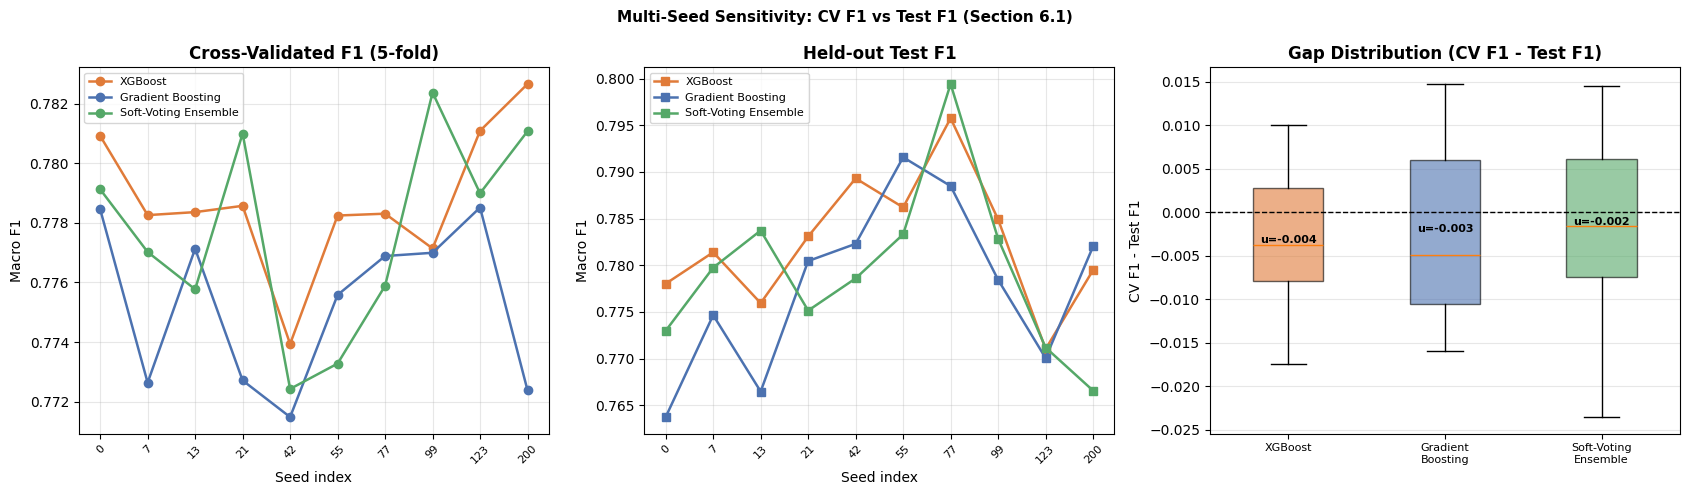

In [ ]:
# ── Multi-Seed Sensitivity Analysis — Section 6.1 ─────────────────────────
SEEDS = [0, 7, 13, 21, 42, 55, 77, 99, 123, 200]
FOCUS_MODELS = ['XGBoost', 'Gradient Boosting', 'Soft-Voting Ensemble']

data_raw = df.copy()
data_raw['target'] = data_raw['fertility_chance'].map(label_map)
X_raw = data_raw.drop(columns=['fertility_chance', 'target'])
y_raw = data_raw['target']

def preprocess_for_seed(X_tr, X_te):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for col in ['bmi', 'alcohol', 'months_trying']:
        q1, q3 = X_tr[col].quantile([0.25, 0.75])
        lo, hi = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
        X_tr[col] = X_tr[col].clip(lo, hi)
        X_te[col] = X_te[col].clip(lo, hi)
    ordinal_maps = {
        'smoking':              {'never':0,'former':1,'light':2,'moderate':3,'heavy':4},
        'activity':             {'sedentary':0,'light':1,'moderate':2,'active':3,'very_active':4},
        'semen_analysis':       {'severe_issue':0,'moderate_issue':1,'mild_issue':2,'normal':3},
        'prior_infertility_dx': {'confirmed':0,'possible':1,'none':2},
    }
    if X_tr['smoking'].dtype == object:
        for split in [X_tr, X_te]:
            for col, mapping in ordinal_maps.items():
                split[col] = split[col].map(mapping)
    for split in [X_tr, X_te]:
        for col in ['amh','fsh','tsh','vitd','semen_analysis']:
            split[f'{col}_missing'] = split[col].isnull().astype(int)
    imp = IterativeImputer(max_iter=10, random_state=42, verbose=0)
    cols_m = ['amh','fsh','tsh','vitd','semen_analysis']
    X_tr[cols_m] = imp.fit_transform(X_tr[cols_m])
    X_te[cols_m] = imp.transform(X_te[cols_m])
    for split in [X_tr, X_te]:
        add_clinical_threshold_features(split)
        add_interaction_features(split)
    return X_tr, X_te

sens_records = []
print(f"{'Seed':>5}  {'Model':<24}  {'CV F1':>8}  {'Test F1':>9}  {'Gap':>7}")
print("-" * 60)

for seed in SEEDS:
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=seed)
    X_tr_s, X_te_s = preprocess_for_seed(X_tr_s, X_te_s)
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    seed_models = {
        'XGBoost': XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            eval_metric='mlogloss', random_state=seed, verbosity=0),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100, max_depth=2, learning_rate=0.1,
            subsample=0.8, random_state=seed),
        'Soft-Voting Ensemble': VotingClassifier(voting='soft', estimators=[
            ('xgb', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                eval_metric='mlogloss', random_state=seed, verbosity=0)),
            ('lgbm', LGBMClassifier(n_estimators=100, num_leaves=31, learning_rate=0.1,
                subsample=0.8, min_child_samples=20, random_state=seed, verbose=-1)),
            ('rf', RandomForestClassifier(n_estimators=100, max_depth=10,
                min_samples_leaf=5, random_state=seed)),
        ]),
    }

    for mname in FOCUS_MODELS:
        pipe = build_pipeline(seed_models[mname])
        cv_scores = cross_val_score(pipe, X_tr_s, y_tr_s, cv=cv_s, scoring='f1_macro', n_jobs=-1)
        pipe.fit(X_tr_s, y_tr_s)
        tf1 = f1_score(y_te_s, pipe.predict(X_te_s), average='macro')
        gap = cv_scores.mean() - tf1
        sens_records.append({'seed':seed,'model':mname,'cv_f1':cv_scores.mean(),'test_f1':tf1,'gap':gap})
        print(f"{seed:>5}  {mname:<24}  {cv_scores.mean():>8.4f}  {tf1:>9.4f}  {gap:>+7.4f}")
    print()

sens_df = pd.DataFrame(sens_records)
print("\nSUMMARY — Mean +/- SD across 10 seeds")
print("=" * 55)
print(sens_df.groupby('model')[['cv_f1','test_f1','gap']].agg(['mean','std']).round(4).to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Multi-Seed Sensitivity: CV F1 vs Test F1 (Section 6.1)", fontsize=11, fontweight='bold')
cmap = {'XGBoost':'#e07b39','Gradient Boosting':'#4c72b0','Soft-Voting Ensemble':'#55a868'}

for mname in FOCUS_MODELS:
    sub = sens_df[sens_df['model']==mname]
    axes[0].plot(range(len(SEEDS)), sub['cv_f1'].values, marker='o', label=mname, color=cmap[mname], linewidth=1.8)
    axes[1].plot(range(len(SEEDS)), sub['test_f1'].values, marker='s', label=mname, color=cmap[mname], linewidth=1.8)

for ax, title in zip(axes[:2], ['Cross-Validated F1 (5-fold)', 'Held-out Test F1']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Seed index'); ax.set_ylabel('Macro F1')
    ax.set_xticks(range(len(SEEDS))); ax.set_xticklabels(SEEDS, fontsize=8, rotation=45)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

gap_data = [sens_df[sens_df['model']==m]['gap'].values for m in FOCUS_MODELS]
bp = axes[2].boxplot(gap_data, patch_artist=True, widths=0.45)
for patch, m in zip(bp['boxes'], FOCUS_MODELS):
    patch.set_facecolor(cmap[m]); patch.set_alpha(0.6)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Gap Distribution (CV F1 - Test F1)', fontweight='bold')
axes[2].set_xticks(range(1, len(FOCUS_MODELS)+1))
axes[2].set_xticklabels([m.replace(' ','\n') for m in FOCUS_MODELS], fontsize=8)
axes[2].set_ylabel('CV F1 - Test F1'); axes[2].grid(True, alpha=0.3, axis='y')
for i, m in enumerate(FOCUS_MODELS, 1):
    mv = sens_df[sens_df['model']==m]['gap'].mean()
    axes[2].text(i, mv, f'u={mv:+.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 6 — Model Evaluation

Confusion matrix · Per-class F1 · ROC curves · Full classification report

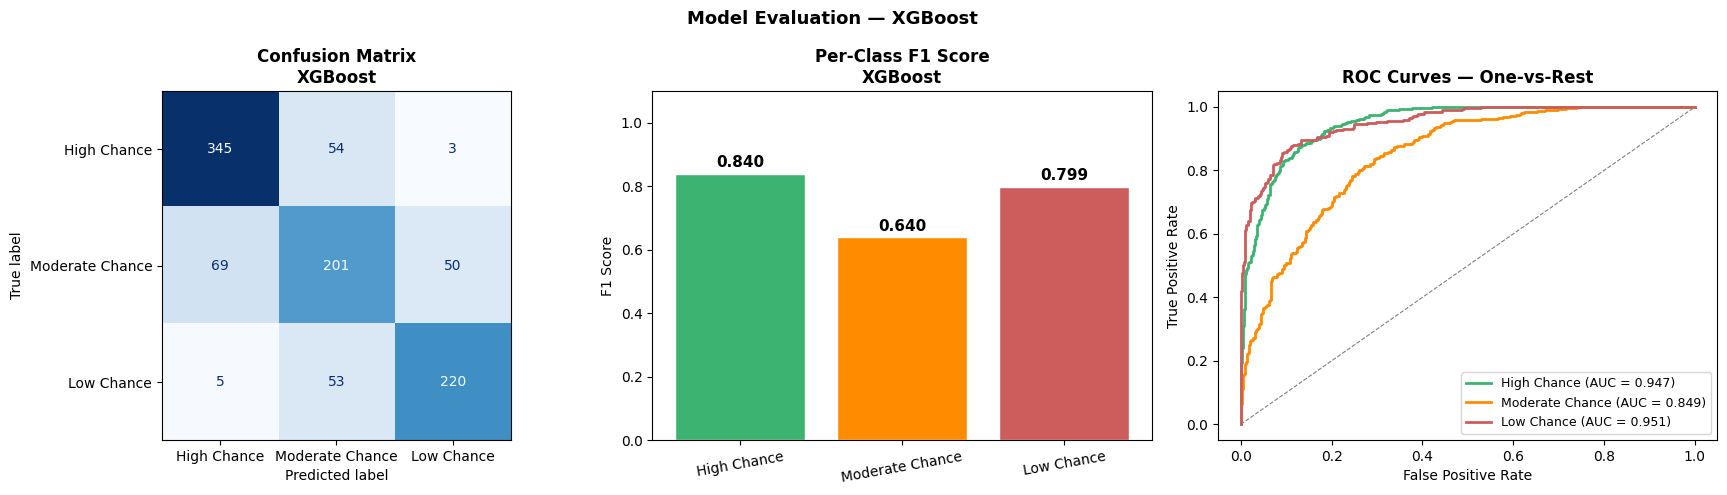

Full Classification Report
                 precision    recall  f1-score   support

    High Chance       0.82      0.86      0.84       402
Moderate Chance       0.65      0.63      0.64       320
     Low Chance       0.81      0.79      0.80       278

       accuracy                           0.77      1000
      macro avg       0.76      0.76      0.76      1000
   weighted avg       0.76      0.77      0.76      1000



In [ ]:
class_display_names = ['High Chance', 'Moderate Chance', 'Low Chance']
class_colors_eval   = ['mediumseagreen', 'darkorange', 'indianred']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix — shown in order: High, Moderate, Low
cm   = confusion_matrix(y_test, y_pred, labels=[2, 1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=class_display_names )
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

# Per-class F1 bar chart
report       = classification_report(y_test, y_pred, labels=[2, 1, 0], target_names=class_display_names , output_dict=True)
f1_per_class = [report[label]['f1-score'] for label in class_display_names ]
bars = axes[1].bar(class_display_names , f1_per_class, color=class_colors_eval, edgecolor='white')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1 Score')
axes[1].set_title(f'Per-Class F1 Score\n{best_name}', fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)
for bar, val in zip(bars, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# One-vs-Rest ROC curves
class_probabilities = best_pipeline.predict_proba(X_test)
class_int_to_name   = {2: 'High Chance', 1: 'Moderate Chance', 0: 'Low Chance'}

for idx, class_int in enumerate([2, 1, 0]):
    binary_labels = (y_test == class_int).astype(int)
    fpr, tpr, _   = roc_curve(binary_labels, class_probabilities[:, class_int])
    auc_score     = roc_auc_score(binary_labels, class_probabilities[:, class_int])
    axes[2].plot(fpr, tpr, lw=2, color=class_colors_eval[idx],
                 label=f'{class_int_to_name[class_int]} (AUC = {auc_score:.3f})')

axes[2].plot([0, 1], [0, 1], color='grey', lw=0.8, linestyle='--')  # random baseline
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves — One-vs-Rest', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle(f'Model Evaluation — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Full Classification Report')
print(classification_report(y_test, y_pred, labels=[2, 1, 0], target_names=class_display_names))

## Step 7 — Feature Importance

Top 20 predictors of fertility chance.  
Green = generally positive for fertility · Red = generally negative.

In [ ]:
# Extract the fitted model and preprocessor from the pipeline
best_model    = best_pipeline.named_steps['model']
preprocessor_ = best_pipeline.named_steps['preprocess']

# Reconstruct feature names (ColumnTransformer reorders columns)
scaled_feature_names      = preprocessor_.transformers_[0][2]
passthrough_feature_names = [col for col in X_train.columns if col not in scaled_feature_names]
all_feature_names         = list(scaled_feature_names) + list(passthrough_feature_names)

# Transform test set (needed for SHAP in the next step)
X_test_transformed    = preprocessor_.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

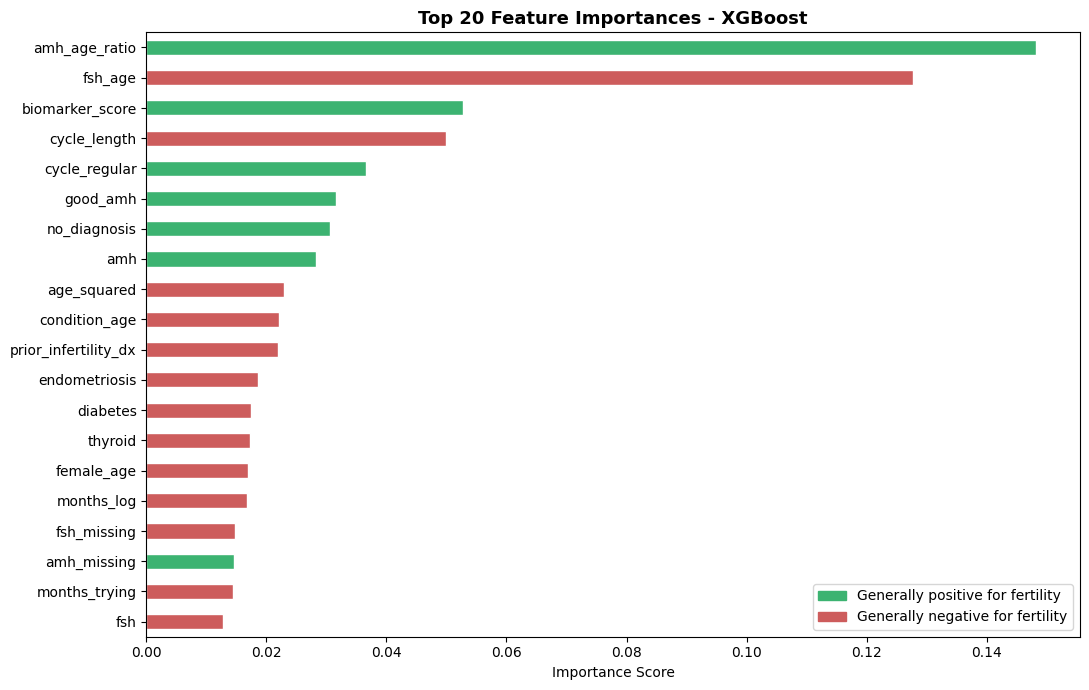

Top 10 most influential features:
   1. amh_age_ratio                       0.1481  [+]
   2. fsh_age                             0.1278  [-]
   3. biomarker_score                     0.0528  [+]
   4. cycle_length                        0.0500  [-]
   5. cycle_regular                       0.0366  [+]
   6. good_amh                            0.0316  [+]
   7. no_diagnosis                        0.0306  [+]
   8. amh                                 0.0283  [+]
   9. age_squared                         0.0229  [-]
  10. condition_age                       0.0221  [-]


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=all_feature_names)
    top_20      = importances.sort_values(ascending=True).tail(20)

    positive_keywords = [
        'amh', 'good', 'prime', 'healthy', 'normal', 'regular',
        'vitd', 'semen', 'no_diag', 'live_births', 'biomarker', 'low_alcohol'
    ]
    bar_colors = [
        'mediumseagreen' if any(kw in col for kw in positive_keywords) else 'indianred'
        for col in top_20.index
    ]

    fig, ax = plt.subplots(figsize=(11, 7))
    top_20.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances - {best_name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance Score')
    ax.legend(handles=[
        mpatches.Patch(color='mediumseagreen', label='Generally positive for fertility'),
        mpatches.Patch(color='indianred',      label='Generally negative for fertility'),
    ])
    plt.tight_layout()
    plt.show()

    print('Top 10 most influential features:')
    for rank, (feat, imp) in enumerate(top_20.sort_values(ascending=False).head(10).items(), start=1):
        direction = '+' if any(kw in feat for kw in positive_keywords) else '-'
        print(f'  {rank:>2}. {feat:<35} {imp:.4f}  [{direction}]')

## Step 8 — SHAP Explainability

Per-prediction feature influence using SHAP TreeExplainer.

SHAP answers: *"For this patient, which features pushed the prediction toward High/Moderate/Low, and by how much?"*

In [ ]:
# Use first 300 test samples for SHAP (computing all 1000 can be slow)
X_shap = X_test_transformed_df.iloc[:300]

# Explicitly convert all columns in X_shap to float type.
# The ColumnTransformer should output numerical data (floats from scaling,
# and integers/booleans from passthrough). When combined into a single
# NumPy array, these often become a common numerical type.
# However, if pandas infers 'object' during DataFrame creation,
# explicitly casting to float resolves this for XGBoost.
X_shap = X_shap.astype(float)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Handle two possible output shapes depending on the model type
if isinstance(shap_values, list):
    # List format: one array per class, index 2 = High Chance
    shap_high   = shap_values[2]
    base_val    = explainer.expected_value[2]
    single_shap = shap_values[2][0]
elif shap_values.ndim == 3:
    # 3D array: (samples, features, classes)
    shap_high   = shap_values[:, :, 2]
    base_val    = explainer.expected_value[2]
    single_shap = shap_values[0, :, 2]
else:
    shap_high   = shap_values
    base_val    = explainer.expected_value
    single_shap = shap_values[0]

print(f'SHAP values computed. Shape: {shap_high.shape}')

SHAP values computed. Shape: (300, 50)


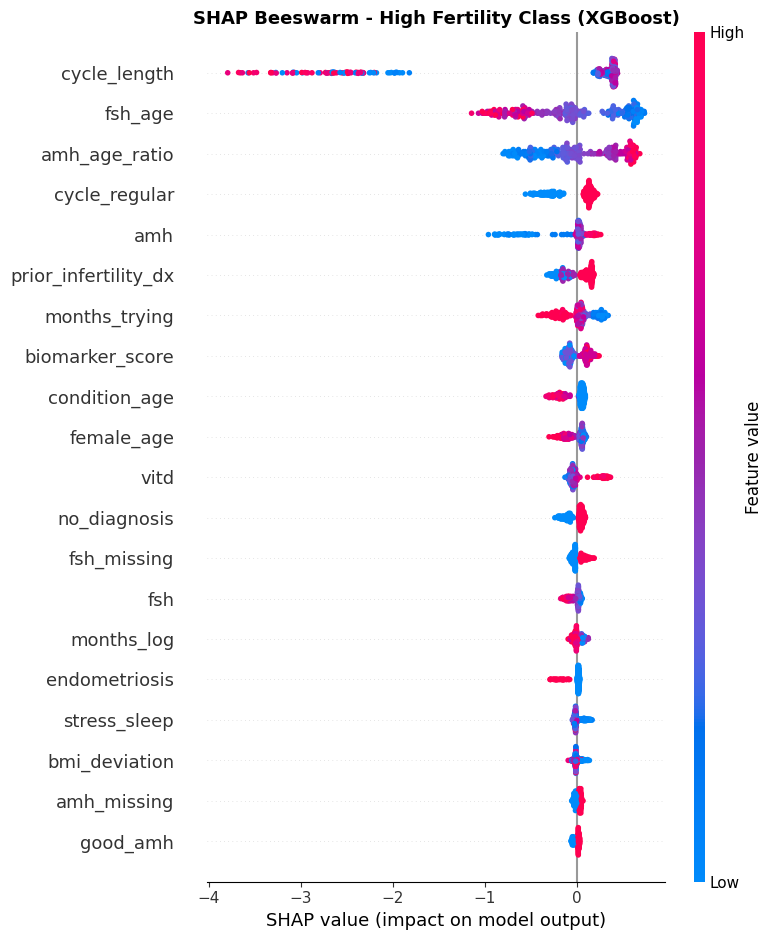

In [ ]:
# Beeswarm: shows distribution of SHAP impact for each feature across all 300 patients
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_high, X_shap, show=False)
plt.title(f'SHAP Beeswarm - High Fertility Class ({best_name})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

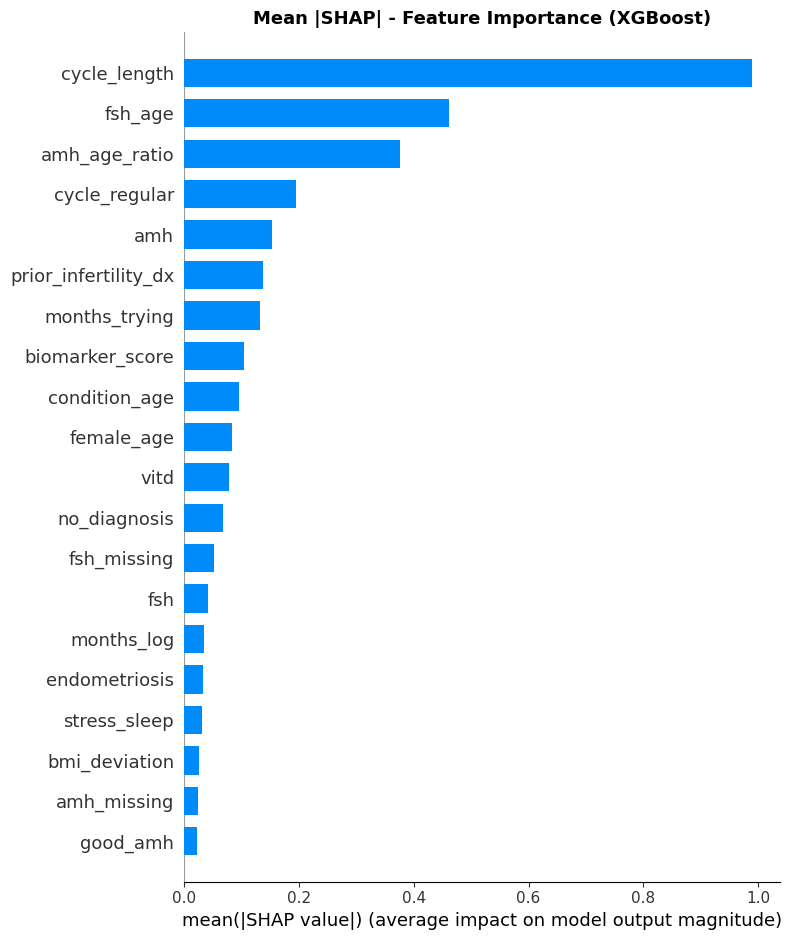

In [ ]:
# Bar plot: mean absolute SHAP value — overall feature importance ranking
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_high, X_shap, plot_type='bar', show=False)
plt.title(f'Mean |SHAP| - Feature Importance ({best_name})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

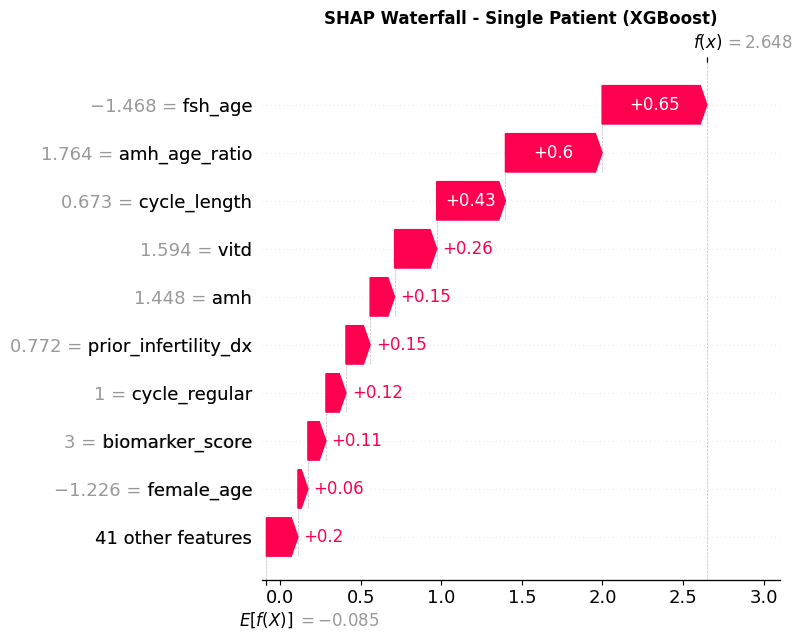

SHAP analysis complete.


In [ ]:
# Waterfall plot: breaks down the prediction for a single patient
single_patient_explanation = shap.Explanation(
    values        = single_shap,
    base_values   = base_val,
    data          = X_shap.iloc[0].values,
    feature_names = all_feature_names
)

plt.figure(figsize=(11, 6))
shap.waterfall_plot(single_patient_explanation, show=False)
plt.title(f'SHAP Waterfall - Single Patient ({best_name})', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('SHAP analysis complete.')

## Step 9 — Sample Inference: Applying the Model to an Illustrative Patient Profile

This section demonstrates how the trained pipeline processes a new, unseen patient record — applying the same preprocessing steps (ordinal encoding, missingness flags, MICE imputation, feature engineering) before passing the record to the fitted classifier.

The profile below is illustrative only. It is included to verify that the inference pipeline is self-consistent and that the SHAP explanations produced in Step 8 translate to individual predictions in a clinically interpretable way. This is not a deployed tool.

| Variable | Accepted values |
|---|---|
| `smoking` | never / former / light / moderate / heavy |
| `activity` | sedentary / light / moderate / active / very_active |
| `semen_analysis` | normal / mild_issue / moderate_issue / severe_issue — or `np.nan` if not tested |
| `prior_infertility_dx` | none / possible / confirmed |
| `amh`, `fsh`, `tsh`, `vitd` | numeric value in appropriate units — or `np.nan` if unavailable |
| Binary columns | 0 = No · 1 = Yes |

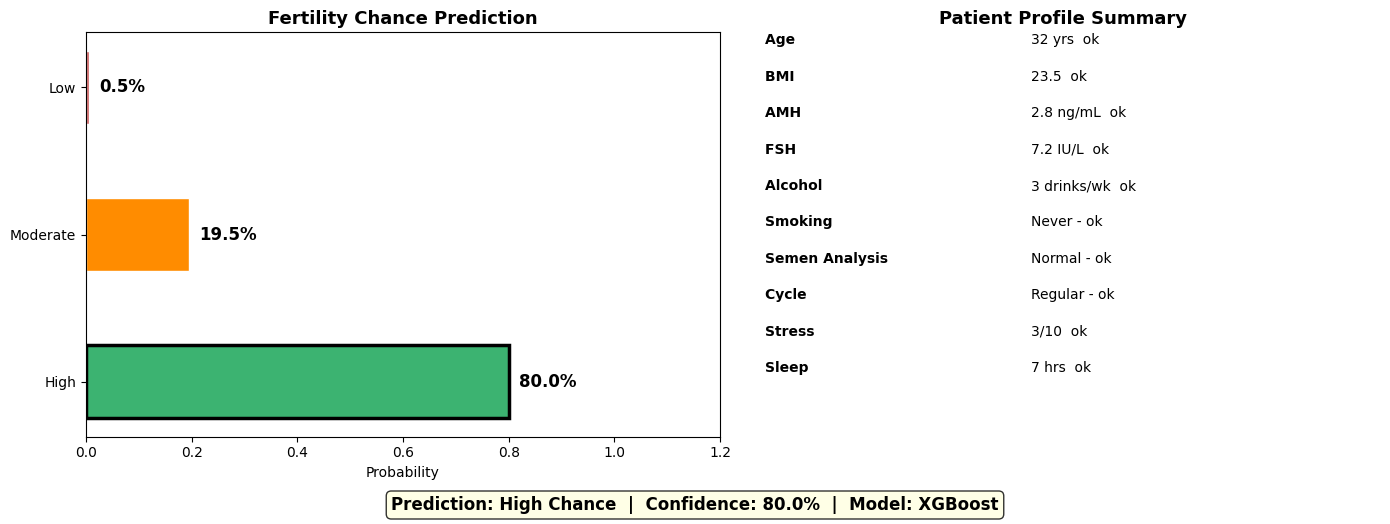

Prediction  : High Chance
Confidence  : 80.0%
Model       : XGBoost

Screening tool only - not a substitute for specialist evaluation.


In [ ]:
# ---- Edit this patient profile -----------------------------------------------
patient_profile = {
    'female_age'           : 32,
    'partner_age'          : 34,
    'months_trying'        : 8,
    'cycle_length'         : 28,
    'cycle_regular'        : 1,
    'ever_pregnant'        : 0,
    'live_births'          : 0,
    'miscarriages'         : 0,
    'ectopic'              : 0,
    'pcos'                 : 0,
    'endometriosis'        : 0,
    'thyroid'              : 0,
    'diabetes'             : 0,
    'bmi'                  : 23.5,
    'smoking'              : 'never',
    'alcohol'              : 3,
    'activity'             : 'moderate',
    'sleep'                : 7,
    'stress'               : 3,
    'amh'                  : 2.8,       # np.nan if not available
    'fsh'                  : 7.2,       # np.nan if not available
    'tsh'                  : 2.1,       # np.nan if not available
    'vitd'                 : 38.0,      # np.nan if not available
    'semen_analysis'       : 'normal',  # np.nan if partner not tested
    'prior_infertility_dx' : 'none',
}
# ------------------------------------------------------------------------------

# Apply the same preprocessing steps as training
patient_df = pd.DataFrame([patient_profile])

for col, mapping in ordinal_maps.items():
    patient_df[col] = patient_df[col].map(mapping)

for col in cols_with_missing:
    patient_df[f'{col}_missing'] = patient_df[col].isnull().astype(int)

# Use the already-fitted imputer (do NOT re-fit on a single patient)
patient_df[cols_with_missing] = imputer.transform(patient_df[cols_with_missing])

add_clinical_threshold_features(patient_df)
add_interaction_features(patient_df)

# Align column order to match what the pipeline expects
patient_final = patient_df[all_feature_names]

patient_probabilities = best_pipeline.predict_proba(patient_final)[0]
predicted_class       = best_pipeline.predict(patient_final)[0]
reverse_label_map    = {2: 'High Chance', 1: 'Moderate Chance', 0: 'Low Chance'}
predicted_label       = reverse_label_map[predicted_class]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability bar chart
class_probs  = [patient_probabilities[2], patient_probabilities[1], patient_probabilities[0]]
class_labels = ['High', 'Moderate', 'Low']
bar_colors   = ['mediumseagreen', 'darkorange', 'indianred']

bars = axes[0].barh(class_labels, class_probs, color=bar_colors, edgecolor='white', height=0.5)
axes[0].set_xlim(0, 1.2)
axes[0].set_title('Fertility Chance Prediction', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Probability')
for bar, prob in zip(bars, class_probs):
    axes[0].text(prob + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{prob:.1%}', va='center', fontsize=12, fontweight='bold')

# Bold border around the predicted class
predicted_idx = class_labels.index(predicted_label.split()[0])
bars[predicted_idx].set_edgecolor('black')
bars[predicted_idx].set_linewidth(2.5)


# Patient profile summary
def ok_or_warn(condition):
    return 'ok' if condition else 'check'

profile_summary = {
    'Age'            : f"{patient_profile['female_age']} yrs  {ok_or_warn(patient_profile['female_age'] <= 35)}",
    'BMI'            : f"{patient_profile['bmi']}  {ok_or_warn(18.5 <= patient_profile['bmi'] <= 25)}",
    'AMH'            : f"{patient_profile['amh']} ng/mL  {ok_or_warn(str(patient_profile['amh']) != 'nan' and patient_profile['amh'] >= 1.5)}",
    'FSH'            : f"{patient_profile['fsh']} IU/L  {ok_or_warn(str(patient_profile['fsh']) != 'nan' and patient_profile['fsh'] <= 8)}",
    'Alcohol'        : f"{patient_profile['alcohol']} drinks/wk  {ok_or_warn(patient_profile['alcohol'] <= 7)}",
    'Smoking'        : 'Never - ok' if patient_profile['smoking'] == 'never' else 'Yes - check',
    'Semen Analysis' : 'Normal - ok' if patient_profile['semen_analysis'] == 'normal' else 'Concern / Not tested - check',
    'Cycle'          : 'Regular - ok' if patient_profile['cycle_regular'] == 1 else 'Irregular - check',
    'Stress'         : f"{patient_profile['stress']}/10  {ok_or_warn(patient_profile['stress'] <= 4)}",
    'Sleep'          : f"{patient_profile['sleep']} hrs  {ok_or_warn(patient_profile['sleep'] >= 7)}",
}

axes[1].axis('off')
axes[1].set_title('Patient Profile Summary', fontweight='bold', fontsize=13)
y_pos = 0.97
for label, value in profile_summary.items():
    axes[1].text(0.03, y_pos, f'{label:<18}', transform=axes[1].transAxes, fontsize=10, fontweight='bold')
    axes[1].text(0.45, y_pos, value,           transform=axes[1].transAxes, fontsize=10)
    y_pos -= 0.09

fig.text(
    0.5, -0.03,
    f'Prediction: {predicted_label}  |  Confidence: {patient_probabilities.max():.1%}  |  Model: {best_name}',
    ha='center', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
plt.tight_layout()
plt.show()

print(f'Prediction  : {predicted_label}')
print(f'Confidence  : {patient_probabilities.max():.1%}')
print(f'Model       : {best_name}')
print('\nNote: This output demonstrates the inference pipeline on a synthetic patient profile.')

## Step 10 — Ablation Study: Does Feature Engineering Improve Performance?

A natural question for any reviewer is whether the engineered features actually improve model performance, or whether tree-based models recover the same information from raw features directly. This section addresses that question by running every model against three progressively richer feature sets under identical cross-validation conditions.

**The result is a null finding — and it is reported as such.**

Across all five models, the difference in CV macro F1 between the raw feature set and the full engineered set is at most 0.007, which is within one standard deviation across folds. This is consistent with what the architecture would predict: gradient boosting methods are specifically designed to discover threshold effects and interaction terms from raw inputs, so explicitly encoding `amh_age_ratio` or `fsh_age` provides little additional signal beyond what XGBoost and LightGBM learn from `amh`, `fsh`, and `female_age` directly.

The engineered features are retained in the final pipeline for a different reason: **interpretability**. Explicitly named features produce more clinically meaningful SHAP explanations. A waterfall plot showing `amh_age_ratio` is more useful to a clinician than separate raw `amh` and `age` contributions. Feature engineering here serves explainability, not predictive performance — and that is a legitimate and defensible design choice.

| Feature Set | Contents |
|---|---|
| **Raw only** | Original 26 features + missingness indicator flags |
| **Raw + threshold** | Above + 8 binary clinical cutoff features (e.g. `good_amh`, `prime_age`) |
| **Raw + threshold + composite** | Above + 12 composite interaction features (e.g. `amh_age_ratio`, `fsh_age`) |

Model                     | Feature Set                         |  CV F1 |   Std
--------------------------------------------------------------------------------
Logistic Regression       | Raw only                            | 0.704 | 0.014
Logistic Regression       | Raw + threshold                     | 0.702 | 0.009
Logistic Regression       | Raw + threshold + composite         | 0.704 | 0.010

Random Forest             | Raw only                            | 0.736 | 0.014
Random Forest             | Raw + threshold                     | 0.729 | 0.015
Random Forest             | Raw + threshold + composite         | 0.729 | 0.010

Gradient Boosting         | Raw only                            | 0.755 | 0.012
Gradient Boosting         | Raw + threshold                     | 0.758 | 0.012
Gradient Boosting         | Raw + threshold + composite         | 0.756 | 0.012

XGBoost                   | Raw only                            | 0.758 | 0.011
XGBoost                   | Raw + t

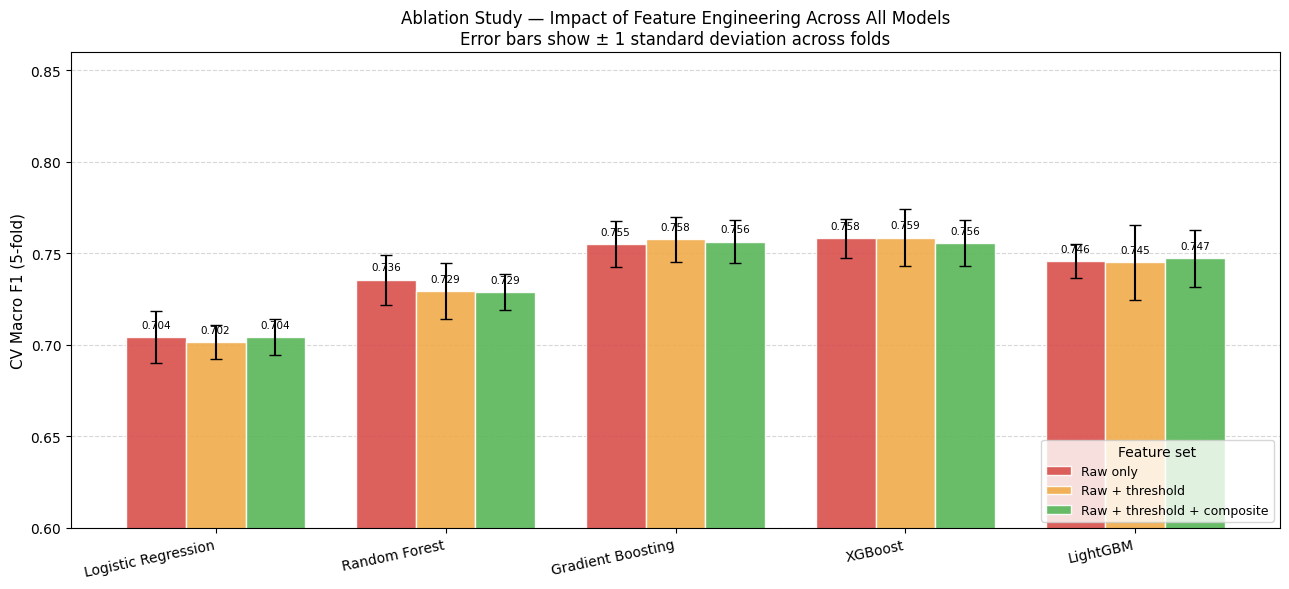

Chart saved as ablation_study.png


In [ ]:
#  Ablation Study: All Models × Three Feature Sets
#
# We test each model on three progressively richer feature sets to show
# that the engineered features earn their place in the pipeline.
# Each run uses the same 5-fold CV + SMOTE-inside-fold setup as the main experiment.

#  Define the three feature sets

# Set 1: just the original 26 columns + missingness flags (no engineering)
raw_only_cols = [
    'female_age', 'partner_age', 'months_trying', 'cycle_length',
    'cycle_regular', 'ever_pregnant', 'live_births', 'miscarriages', 'ectopic',
    'pcos', 'endometriosis', 'thyroid', 'diabetes', 'bmi',
    'smoking', 'alcohol', 'activity', 'sleep', 'stress',
    'amh', 'fsh', 'tsh', 'vitd', 'semen_analysis', 'prior_infertility_dx',
    'amh_missing', 'fsh_missing', 'tsh_missing', 'vitd_missing', 'semen_analysis_missing'
]

# Set 2: raw + the 8 binary clinical threshold flags
threshold_cols = raw_only_cols + [
    'prime_age', 'healthy_bmi', 'good_amh', 'normal_fsh',
    'optimal_vitd', 'low_alcohol', 'no_diagnosis', 'healthy_habits'
]

# Set 3: everything — raw + threshold + 12 composite interaction features
all_cols = threshold_cols + [
    'biomarker_score', 'total_conditions', 'repro_history', 'lifestyle_score',
    'amh_age_ratio', 'fsh_age', 'age_squared', 'months_log',
    'bmi_deviation', 'stress_sleep', 'condition_age', 'alcohol_age'
]

feature_sets = {
    'Raw only':                    raw_only_cols,
    'Raw + threshold':             threshold_cols,
    'Raw + threshold + composite': all_cols,
}

# ── Models to test (same hyperparameters as the main experiment) ──────────────
ablation_models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   min_samples_leaf=5, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=2,
                                                       learning_rate=0.1, subsample=0.8,
                                                       random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                          subsample=0.8, colsample_bytree=0.8,
                                          min_child_weight=5, eval_metric='mlogloss',
                                          random_state=42, verbosity=0),
    'LightGBM':            LGBMClassifier(n_estimators=100, num_leaves=31, learning_rate=0.1,
                                           subsample=0.8, min_child_samples=20,
                                           random_state=42, verbose=-1),
}

#  Run the ablation
cv_ablation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ablation_results = {model_name: {} for model_name in ablation_models}

print(f"{'Model':<25} | {'Feature Set':<35} | {'CV F1':>6} | {'Std':>5}")
print('-' * 80)

for model_name, model in ablation_models.items():
    for feat_label, feat_cols in feature_sets.items():

        # Only use columns that exist in X_train (guard against name mismatches)
        available_cols = [c for c in feat_cols if c in X_train.columns]
        X_subset       = X_train[available_cols]

        # Scale continuous columns only — same logic as the main pipeline
        cont_cols_abl = X_subset.select_dtypes(include=['float64']).columns.tolist()
        scaler_abl    = ColumnTransformer(
            [('scale', StandardScaler(), cont_cols_abl)],
            remainder='passthrough'
        )

        pipe_abl = ImbPipeline([
            ('scaler', scaler_abl),
            ('smote',  SMOTE(random_state=42, k_neighbors=5)),
            ('model',  model)
        ])

        scores = cross_val_score(
            pipe_abl, X_subset, y_train,
            cv=cv_ablation, scoring='f1_macro', n_jobs=-1
        )
        ablation_results[model_name][feat_label] = {
            'mean': scores.mean(),
            'std':  scores.std()
        }
        print(f"{model_name:<25} | {feat_label:<35} | {scores.mean():.3f} | {scores.std():.3f}")

    print()  # blank line between models for readability

# Summary table
print('\nSummary — CV Macro F1 by model and feature set:')
summary_rows = []
for model_name in ablation_models:
    row = {'Model': model_name}
    for feat_label in feature_sets:
        row[feat_label] = round(ablation_results[model_name][feat_label]['mean'], 3)
    summary_rows.append(row)

ablation_summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(ablation_summary_df.to_string())

#  Grouped bar chart
fig, ax = plt.subplots(figsize=(13, 6))

model_names_abl = list(ablation_models.keys())
feat_labels     = list(feature_sets.keys())
x               = np.arange(len(model_names_abl))
width           = 0.26
bar_colors      = ['#d9534f', '#f0ad4e', '#5cb85c']  # red → amber → green

for i, (feat_label, color) in enumerate(zip(feat_labels, bar_colors)):
    means  = [ablation_results[m][feat_label]['mean'] for m in model_names_abl]
    stds   = [ablation_results[m][feat_label]['std']  for m in model_names_abl]
    offset = (i - 1) * width  # centres the three bars around each tick
    bars   = ax.bar(
        x + offset, means, width,
        yerr=stds, capsize=4,
        label=feat_label, color=color,
        edgecolor='white', alpha=0.92
    )
    # Label each bar with its F1 value
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f'{mean:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x)
ax.set_xticklabels(model_names_abl, rotation=12, ha='right', fontsize=10)
ax.set_ylabel('CV Macro F1 (5-fold)', fontsize=11)
ax.set_title(
    'Ablation Study — Impact of Feature Engineering Across All Models\n'
    'Error bars show ± 1 standard deviation across folds',
    fontsize=12
)
ax.set_ylim(0.60, 0.86)
ax.legend(title='Feature set', loc='lower right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as ablation_study.png')

## Step 11 — Final Results Summary


In [ ]:
final_report = classification_report(
    y_test, y_pred, labels=[2, 1, 0],
    target_names=['High', 'Moderate', 'Low'], output_dict=True
)


print('   MACHINE LEARNING FERTILITY CLASSIFICATION — RESULTS SUMMARY')

print(f'  Best model        : {best_name}')
print(f'  Dataset           : fertility_final_5000_v8.csv')
print(f'  Original features : 26')
print(f'  Total features    : {X_train.shape[1]} (after engineering)')
print(f'  Train size        : {len(X_train):,}')
print(f'  Test size         : {len(X_test):,}')
print(f'  CV Macro F1       : {results[best_name]["cv_mean"]:.4f} (+-{results[best_name]["cv_std"]:.4f})')
print(f'  Test Macro F1     : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'  Test Accuracy     : {accuracy_score(y_test, y_pred):.4f}')
print()
print(f"  {'Class':<14} {'F1':>6}  {'Precision':>10}  {'Recall':>8}  {'Support':>8}")

for cls in ['High', 'Moderate', 'Low']:
    r = final_report[cls]
    print(f"  {cls:<14} {r['f1-score']:>6.3f}  {r['precision']:>10.3f}  {r['recall']:>8.3f}  {int(r['support']):>8}")



   FERTILITY CHANCE PREDICTION - FINAL SUMMARY
  Best model        : XGBoost
  Dataset           : fertility_final_5000_v8.csv
  Original features : 26
  Total features    : 50 (after engineering)
  Train size        : 4,000
  Test size         : 1,000
  CV Macro F1       : 0.7567 (+-0.0099)
  Test Macro F1     : 0.7597
  Test Accuracy     : 0.7660

  Class              F1   Precision    Recall   Support
  ----------------------------------------------------
  High            0.840       0.823     0.858       402
  Moderate        0.640       0.653     0.628       320
  Low             0.799       0.806     0.791       278
  Screening tool only - not for clinical use without specialist evaluation.
